In [53]:
import kagglehub
import os 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
# Download latest version
path = kagglehub.dataset_download("vishakhdapat/customer-segmentation-clustering")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\rhitb\.cache\kagglehub\datasets\vishakhdapat\customer-segmentation-clustering\versions\1


In [54]:
files= os.listdir(path) 
way=path+'//'+files[0] 
df=pd.read_csv(way)

In [55]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [56]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [58]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [59]:
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)

In [60]:
df['Age']= 2025-df['Year_Birth']

In [61]:
df['Total_children']=df['Kidhome']+df['Teenhome']

In [62]:
df.drop(columns=['Kidhome','Teenhome'],inplace=True)

In [63]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children
0,5524,1957,Graduation,Single,58138.0,2012-09-04,58,635,88,546,...,0,0,0,0,0,3,11,1,68,0
1,2174,1954,Graduation,Single,46344.0,2014-03-08,38,11,1,6,...,0,0,0,0,0,3,11,0,71,2
2,4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,...,0,0,0,0,0,3,11,0,60,0
3,6182,1984,Graduation,Together,26646.0,2014-02-10,26,11,4,20,...,0,0,0,0,0,3,11,0,41,1
4,5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,...,0,0,0,0,0,3,11,0,44,1


In [64]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Total_children'],
      dtype='object')

In [65]:
spend_cols=['MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts']

In [66]:
df['Total_Spending']=df[spend_cols].sum(axis=1)

In [67]:
df['Total_Spending']

0       1529
1         21
2        734
3         48
4        407
        ... 
2235    1094
2236     436
2237    1217
2238     782
2239     151
Name: Total_Spending, Length: 2240, dtype: int64

In [68]:
df['customer_since']=(pd.Timestamp('today')-df['Dt_Customer']).dt.days

In [69]:
df['customer_since']

0       4936
1       4386
2       4585
3       4412
4       4434
        ... 
2235    4654
2236    4292
2237    4428
2238    4429
2239    4895
Name: customer_since, Length: 2240, dtype: int64

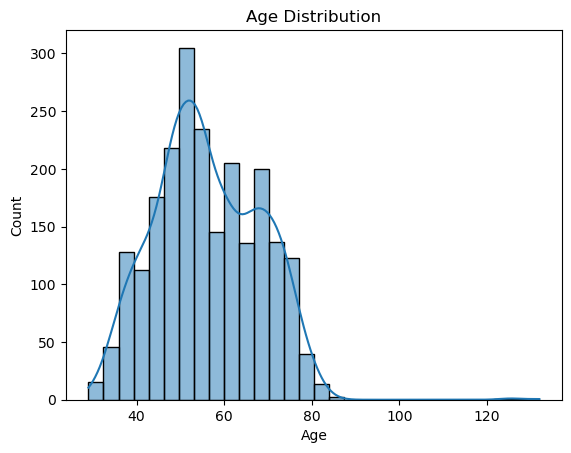

In [70]:
sns.histplot(df['Age'],bins=30,kde=True)
plt.title('Age Distribution')
plt.show()

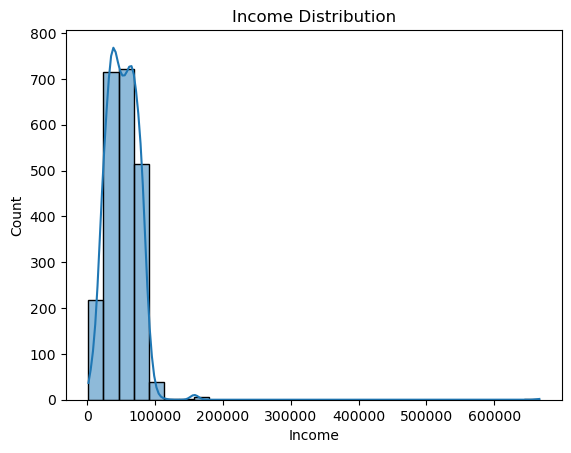

In [71]:
sns.histplot(df['Income'],bins=30,kde=True)
plt.title('Income Distribution')
plt.show()

In [72]:
corr=df[['Income','Age','Total_Spending','NumWebPurchases','NumStorePurchases']].corr()

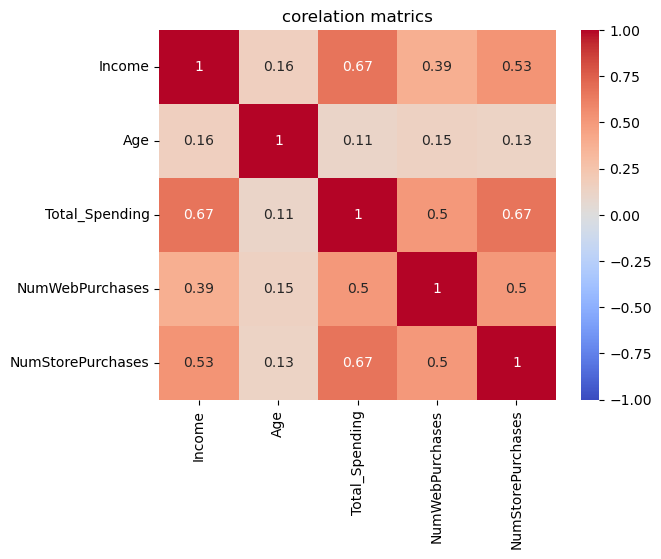

In [73]:
sns.heatmap(corr,annot=True,cmap='coolwarm',vmax=1,vmin=-1)
plt.title('corelation matrics')
plt.show()

In [74]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Total_children', 'Total_Spending', 'customer_since'],
      dtype='object')

In [75]:
df['Acceptedany'] = df[['AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp1','AcceptedCmp2']].max(axis=1)

In [76]:
df['Acceptedany'].unique()

array([0, 1], dtype=int64)

In [77]:
df.drop(columns=['AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp1','AcceptedCmp2'],inplace=True)

<Axes: xlabel='Marital_Status'>

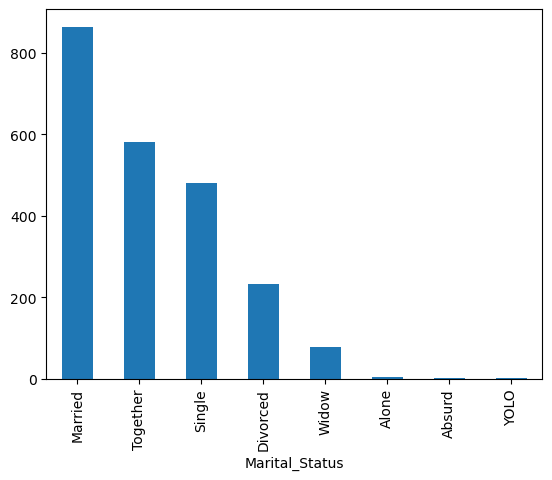

In [78]:
df['Marital_Status'].value_counts().plot(kind='bar')

In [79]:
df['Marital_Status']=df['Marital_Status'].map({'Together':'Married','Alone':'Single','Divorced':'Single','YOLO':'Other','Absurd':'Other'})

In [80]:
df['Marital_Status'].value_counts()

Marital_Status
Married    580
Single     235
Other        4
Name: count, dtype: int64

<Axes: xlabel='Marital_Status'>

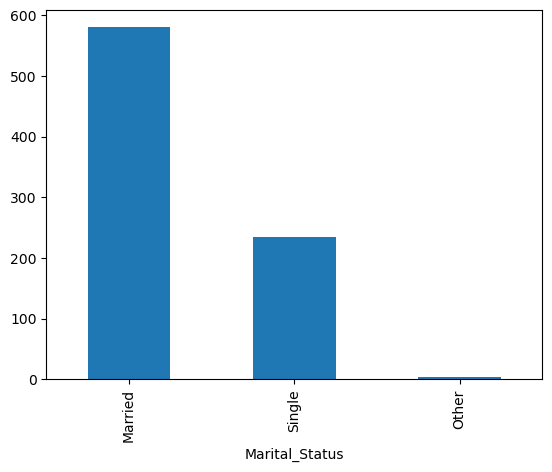

In [81]:
df['Marital_Status'].value_counts().plot(kind='bar')

In [82]:
bins=[18,30,40,50,60,70,90]

In [83]:
labels=['18-29','30-39','40-49','50-59','60-69','70+']

In [84]:
df['Age_group']=pd.cut(df['Age'],bins=bins,labels=labels)

In [85]:
group_1=df.groupby('Age_group')['Income'].mean()

C:\Users\rhitb\AppData\Local\Temp\ipykernel_12220\3251388416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_1=df.groupby('Age_group')['Income'].mean()


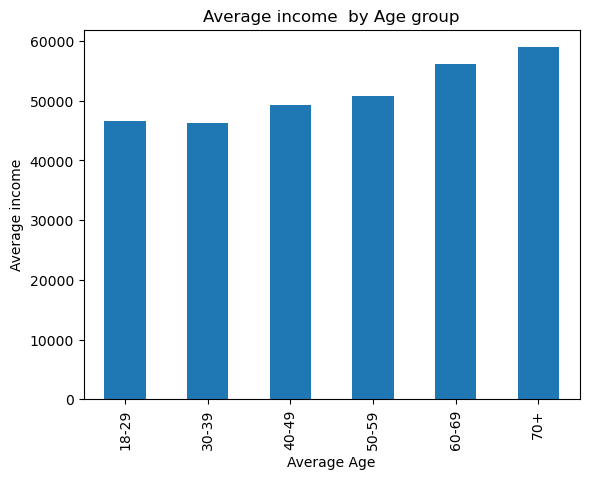

In [86]:
group_1.plot(kind='bar')
plt.title('Average income  by Age group')
plt.xlabel('Average Age')
plt.ylabel('Average income')
plt.show()

In [87]:
features=['Age','Income','Total_Spending','NumStorePurchases','NumWebPurchases','Recency']

In [88]:
X=df[features].copy()

In [89]:
X

,Age,Income,Total_Spending,NumStorePurchases,NumWebPurchases,Recency
0,68,58138.0,1529,4,8,58
1,71,46344.0,21,2,1,38
2,60,71613.0,734,10,8,26
3,41,26646.0,48,4,2,26
4,44,58293.0,407,6,5,94
...,...,...,...,...,...,...
2235,58,61223.0,1094,4,9,46
2236,79,64014.0,436,5,8,56
2237,44,56981.0,1217,13,2,91
2238,69,69245.0,782,10,6,8


In [90]:
X['Income']=X['Income'].fillna(X['Income'].mean())

In [91]:
from sklearn.preprocessing import StandardScaler

In [92]:
scaler=StandardScaler()

In [93]:
X_scaled=scaler.fit_transform(X)

In [94]:
from sklearn.cluster import KMeans

In [95]:
wcss=[] 
for i in range(2,10):
    kmean =KMeans(n_clusters=i)
    kmean.fit(X_scaled)
    wcss.append(kmean.inertia_)

In [96]:
print(wcss)

[8703.584603837715, 7783.936538700559, 6961.684249694255, 6595.8013228453265, 6049.548343684284, 5597.389281510207, 5167.580062223983, 5027.3133755371655]


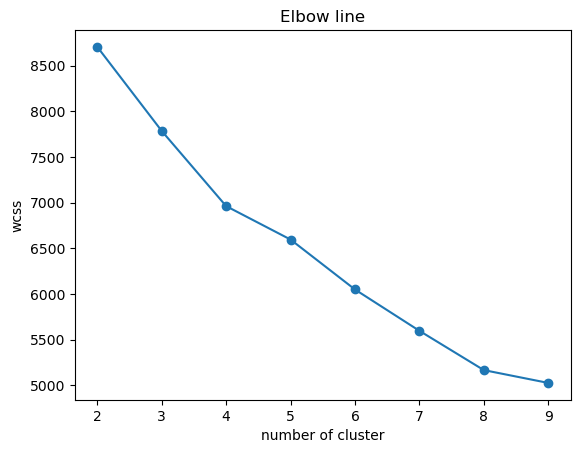

In [97]:
plt.plot(range(2,10),wcss,marker='o')
plt.title('Elbow line')
plt.xlabel('number of cluster')
plt.ylabel('wcss')
plt.show()

In [98]:
kmean=KMeans(n_clusters=6)
df['Cluster']=kmean.fit_predict(X_scaled)

In [99]:
df['Cluster']

0       1
1       0
2       3
3       0
4       2
       ..
2235    3
2236    5
2237    4
2238    3
2239    5
Name: Cluster, Length: 2240, dtype: int32

In [100]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_Spending,customer_since,Acceptedany,Age_group,Cluster
0,5524,1957,Graduation,NaN,58138.0,2012-09-04,58,635,88,546,...,3,11,1,68,0,1529,4936,0,60-69,1
1,2174,1954,Graduation,NaN,46344.0,2014-03-08,38,11,1,6,...,3,11,0,71,2,21,4386,0,70+,0
2,4141,1965,Graduation,Married,71613.0,2013-08-21,26,426,49,127,...,3,11,0,60,0,734,4585,0,50-59,3
3,6182,1984,Graduation,Married,26646.0,2014-02-10,26,11,4,20,...,3,11,0,41,1,48,4412,0,40-49,0
4,5324,1981,PhD,NaN,58293.0,2014-01-19,94,173,43,118,...,3,11,0,44,1,407,4434,0,40-49,2


In [111]:
Cluster_summary=df.groupby('Cluster')[features].mean().reset_index()

In [112]:
Cluster_summary

,Cluster,Age,Income,Total_Spending,NumStorePurchases,NumWebPurchases,Recency
0,0,52.250958,33556.889535,84.576628,3.170498,2.068966,24.375479
1,1,62.520661,83135.336100,1565.487603,7.896694,4.611570,54.491736
2,2,51.537313,33872.656587,89.656716,3.200426,2.142857,75.285714
3,3,61.860274,62853.892265,779.235616,7.991781,6.854795,21.046575
4,4,47.023055,68895.505814,1066.219020,9.475504,5.896254,61.100865
5,5,69.162712,56181.844828,470.962712,5.755932,4.749153,67.461017


In [ ]:
#cluster 0 =👉 Low-income low spenders but somewhat active customers
#These customers: buy occasionally ,spend very little, recently purchased something

# Strategy:- Discounts , Small promotions, Budget products

In [ ]:
# Cluster 1 :- 👉 High-income high-value customers (VIP customers) 

# these custome spend a lot and have high purchasing power 
# Strategy:- Premium offers, Loyalty programs ,Exclusive deals

In [ ]:
# cluster 2:- 👉 Low-income inactive customers

# These customer spend very little and haven't purchased recently

# Strategy:- Re-engagement campaigns,Special offers

In [ ]:
# cluster 3"- 👉 Active multi-channel customers
# These customers shop online and offline and spend medium-high amount

# Strategy:- Cross-selling

In [ ]:
# Cluster 4:- 👉 Frequent store shoppers
# These customers prefer physical store shopping and spend a lot

# strategy :- Membership benefits and In-store promotions

In [ ]:
# Cluster 5:-👉 Older moderate spenders

# These customers are from older age group,moderate income and moderate spending

# Strategy:-easy purchase channels
